# **Evaluación Sumativa — Unidad 2: Inferencia Estadística Paramétrica**
**Dataset:** Remuneraciones e Ingresos Adicionales — Municipio de Loja

**Estudiante:** José Valencia | **Grupo:** H

## **Objetivo**
Aplicar pruebas de hipótesis paramétricas (T de Student) y A/B Testing
sobre el dataset regional del Municipio de Loja para validar científicamente
suposiciones críticas sobre la estructura salarial de la provincia.

In [5]:
# Importar Librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
print("Librerias importadas correctamente")

Librerias importadas correctamente


In [6]:
from google.colab import files
uploaded = files.upload()

Saving 3._remuneraciones_ingresos_adicionales.xlsx to 3._remuneraciones_ingresos_adicionales (1).xlsx


In [8]:
df = pd.read_excel('3._remuneraciones_ingresos_adicionales.xlsx')

print(f"Registros totales:  {len(df)}")
print(f"Variables        :  {len(df.columns)}")
print(f"\nRegimen laboral: ")
print(df['Régimen laboral al que pertenece\xa0'].value_counts())

Registros totales:  2883
Variables        :  12

Regimen laboral: 
Régimen laboral al que pertenece 
LOSEP                1425
CODIGO DE TRABAJO    1308
LOSEP-SOC             139
LOSEP-CONCEJAL         11
Name: count, dtype: int64


---
## **Parte 1 — Prueba de Hipótesis Unimuestral (T de Student)**

### **Planteamiento**

Se evalúa si la **remuneración mensual unificada promedio** de los
empleados del Municipio de Loja es significativamente diferente del
salario de referencia de **$600**, valor que representa el umbral
salarial bajo en el contexto regional ecuatoriano.

$$H_0: \mu = 600 \quad \text{(la remuneración media es } \$600\text{)}$$
$$H_1: \mu \neq 600 \quad \text{(la remuneración media es diferente de } \$600\text{)}$$

Como $n = 2883 \geq 30$ y la varianza poblacional es desconocida,
se aplica la **distribución T de Student**:

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

In [11]:
# Parte 1: Prueba T Unimuestral

col = 'Remuneración mensual unificada'
datos = df[col].dropna()
alpha = 0.05
mu_0 = 600

# Estadisticos Descriptivos
n = len(datos)
media = datos.mean()
std = datos.std(ddof=1)
ee = std / np.sqrt(n)
gl = n - 1

# Prueba T Unimuestral
t_stat, p_val = stats.ttest_1samp(datos, popmean=mu_0, alternative='two-sided')

print("=" * 55)
print("  PRUEBA T UNIMUESTRAL — REMUNERACIÓN MENSUAL")
print("=" * 55)
print(f"  n                          : {n}")
print(f"  Media muestral  (x̄)        : ${media:.2f}")
print(f"  Desv. estándar  (s)        : ${std:.2f}")
print(f"  Error estándar  (SE)       : ${ee:.4f}")
print(f"  Grados de libertad (gl)    : {gl}")
print(f"  μ₀ (valor hipotético)      : ${mu_0:.2f}")
print(f"  Estadístico t              : {t_stat:.4f}")
print(f"  Valor-p                    : {p_val:.2e}")
print(f"  Nivel de significancia (α) : {alpha}")
print("=" * 55)

if p_val < alpha:
    print(f"  DECISIÓN: Se RECHAZA H₀")
    print(f"  La remuneración media (${media:.2f}) es")
    print(f"  significativamente diferente de ${mu_0}.")
else:
    print(f"  DECISIÓN: No se rechaza H₀")


  PRUEBA T UNIMUESTRAL — REMUNERACIÓN MENSUAL
  n                          : 2883
  Media muestral  (x̄)        : $713.81
  Desv. estándar  (s)        : $265.10
  Error estándar  (SE)       : $4.9372
  Grados de libertad (gl)    : 2882
  μ₀ (valor hipotético)      : $600.00
  Estadístico t              : 23.0511
  Valor-p                    : 4.79e-108
  Nivel de significancia (α) : 0.05
  DECISIÓN: Se RECHAZA H₀
  La remuneración media ($713.81) es
  significativamente diferente de $600.


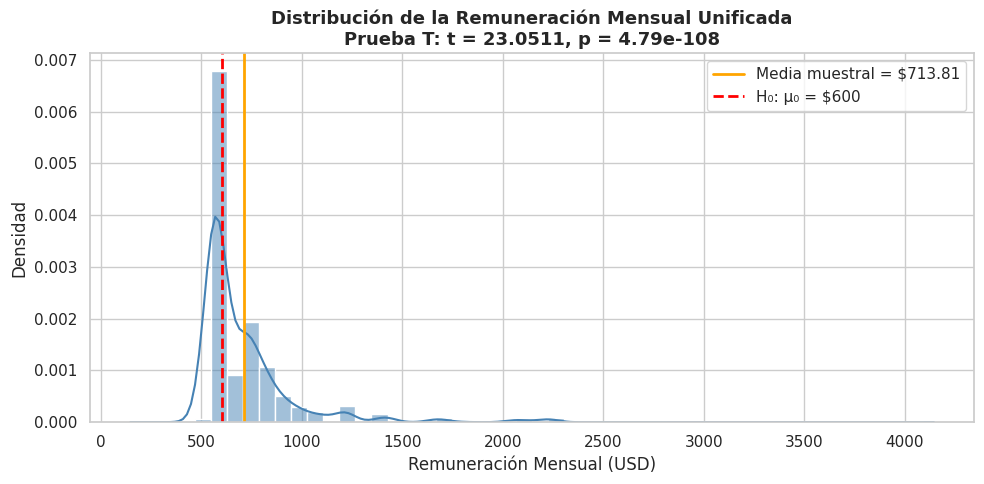

In [13]:
# Visualización Parte 1
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(datos, bins=50, kde=True, color='steelblue',
             alpha=0.5, stat='density', ax=ax)

ax.axvline(media, color='orange', linestyle='-',
           linewidth=2, label=f'Media muestral = ${media:.2f}')
ax.axvline(mu_0, color='red', linestyle='--',
           linewidth=2, label=f'H₀: μ₀ = ${mu_0}')
ax.set_title('Distribución de la Remuneración Mensual Unificada\n'
             f'Prueba T: t = {t_stat:.4f}, p = {p_val:.2e}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Remuneración Mensual (USD)')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()


### **Interpretación de la Parte 1**

El estadístico $t = 23.0511$ con $gl = 2882$ y $\text{valor-p} \approx 0$
es extremadamente alejado de cero. Como $\text{valor-p} \ll \alpha = 0.05$,
se **rechaza H₀** con evidencia contundente.

La remuneración mensual promedio real de los empleados municipales
($\bar{x} = \$713.81$) es significativamente mayor que el valor de
referencia de $\$600$, lo que indica que la estructura salarial del
Municipio de Loja supera ese umbral de forma estadísticamente probada.



## **Parte 2 — A/B Testing: Comparación entre Regímenes Laborales**

### **Planteamiento**

Se compara la remuneración mensual entre dos grupos:

- **Grupo A:** empleados bajo **Código de Trabajo** ($n_A = 1308$)
- **Grupo B:** empleados bajo **LOSEP** ($n_B = 1425$)

$$H_0: \mu_A = \mu_B \quad \text{(no existe diferencia entre regímenes)}$$
$$H_1: \mu_A \neq \mu_B \quad \text{(existe diferencia significativa)}$$

Dado que las varianzas pueden diferir entre grupos, se aplica el
**Test de Levene** para validar homocedasticidad, y en función de
ese resultado se elige entre T clásica o **T de Welch**:

$$t_{Welch} = \frac{\bar{x}_A - \bar{x}_B}{\sqrt{\dfrac{s_A^2}{n_A} + \dfrac{s_B^2}{n_B}}}$$

$$df_{Welch} = \frac{\left(\dfrac{s_A^2}{n_A} + \dfrac{s_B^2}{n_B}\right)^2}{\dfrac{(s_A^2/n_A)^2}{n_A-1} + \dfrac{(s_B^2/n_B)^2}{n_B-1}}$$

In [14]:
#  Parte 2: A/B Testing

regimen = df['Régimen laboral al que pertenece\xa0']
grupo_a = df[regimen == 'CODIGO DE TRABAJO'][col].dropna()
grupo_b = df[regimen == 'LOSEP'][col].dropna()

# Estadisticos descriptivos por grupo

print("=" * 55)
print("  ESTADÍSTICOS POR GRUPO")
print("=" * 55)
print(f"  Grupo A (Código de Trabajo)")
print(f"    n      : {len(grupo_a)}")
print(f"    Media  : ${grupo_a.mean():.2f}")
print(f"    Std    : ${grupo_a.std(ddof=1):.2f}")
print(f"\n  Grupo B (LOSEP)")
print(f"    n      : {len(grupo_b)}")
print(f"    Media  : ${grupo_b.mean():.2f}")
print(f"    Std    : ${grupo_b.std(ddof=1):.2f}")
print("=" * 55)


# Test de Levene (homocedasticidad)
lev_stat, lev_p = stats.levene(grupo_a, grupo_b)
print(f"\n  TEST DE LEVENE")
print(f"  Estadístico : {lev_stat:.4f}")
print(f"  Valor-p     : {lev_p:.4e}")

if lev_p < 0.05:
    print("  Varianzas NO homogéneas → se usa T de Welch")
    equal_var = False
else:
    print("  Varianzas homogéneas → se usa T clásica")
    equal_var = True

# Prueba T de Welch (dos colas)
t2, p2 = stats.ttest_ind(grupo_a, grupo_b,
                          equal_var=equal_var,
                          alternative='two-sided')

# Grados de libertad de Welch
s1, s2 = grupo_a.std(ddof=1), grupo_b.std(ddof=1)
n1, n2 = len(grupo_a), len(grupo_b)
num = (s1**2/n1 + s2**2/n2)**2
den = (s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1)
gl_welch = num / den

# Tamaño del efecto (Cohen's d)
pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2)/(n1+n2-2))
cohens_d = abs((grupo_a.mean() - grupo_b.mean()) / pooled)

print(f"\n  PRUEBA T DE WELCH (A/B Testing)")
print("=" * 55)
print(f"  Estadístico t              : {t2:.4f}")
print(f"  Grados de libertad (Welch) : {gl_welch:.2f}")
print(f"  Valor-p                    : {p2:.2e}")
print(f"  Cohen's d                  : {cohens_d:.4f}")
print("=" * 55)

if p2 < alpha:
    print(f"  DECISIÓN: Se RECHAZA H₀")
    print(f"  Existe diferencia significativa entre regímenes.")
else:
    print(f"  DECISIÓN: No se rechaza H₀")


  ESTADÍSTICOS POR GRUPO
  Grupo A (Código de Trabajo)
    n      : 1308
    Media  : $576.60
    Std    : $44.26

  Grupo B (LOSEP)
    n      : 1425
    Media  : $829.17
    Std    : $303.95

  TEST DE LEVENE
  Estadístico : 407.0554
  Valor-p     : 1.7116e-84
  Varianzas NO homogéneas → se usa T de Welch

  PRUEBA T DE WELCH (A/B Testing)
  Estadístico t              : -31.0115
  Grados de libertad (Welch) : 1489.70
  Valor-p                    : 2.47e-163
  Cohen's d                  : 1.1397
  DECISIÓN: Se RECHAZA H₀
  Existe diferencia significativa entre regímenes.


/tmp/ipykernel_3886/1441954628.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x='Régimen', y='Remuneración',


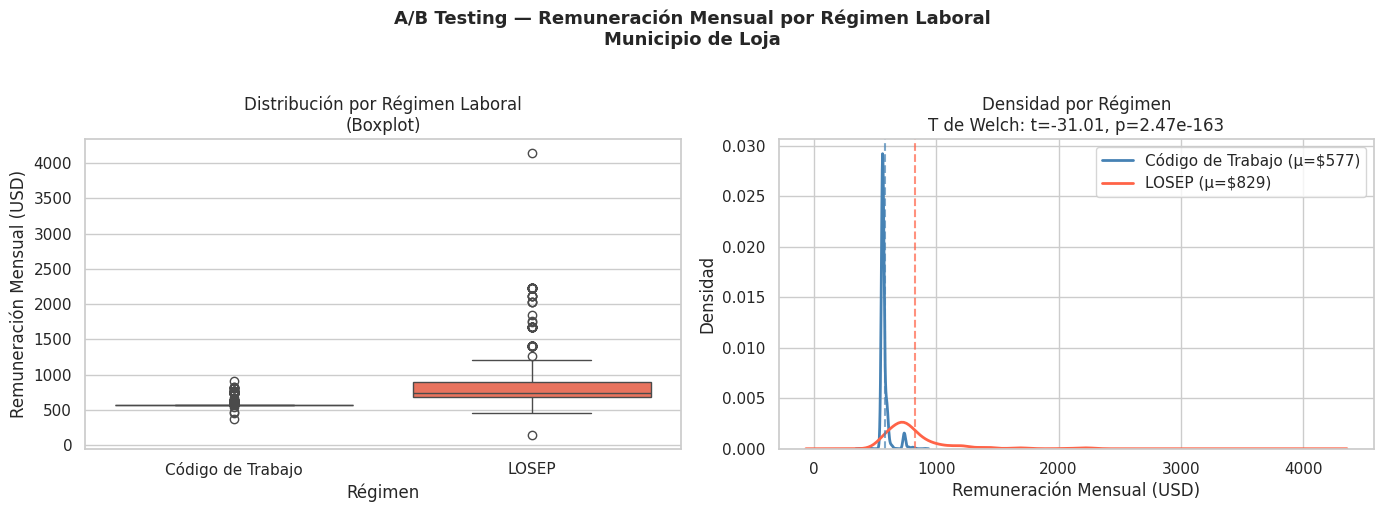

In [15]:
# Visualización A/B Testing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot comparativo
data_plot = pd.DataFrame({
    'Remuneración': pd.concat([grupo_a, grupo_b]),
    'Régimen': ['Código de Trabajo']*len(grupo_a) + ['LOSEP']*len(grupo_b)
})

sns.boxplot(data=data_plot, x='Régimen', y='Remuneración',
            palette=['steelblue', 'tomato'], ax=axes[0])
axes[0].set_title('Distribución por Régimen Laboral\n(Boxplot)', fontsize=12)
axes[0].set_ylabel('Remuneración Mensual (USD)')

# KDE superpuesto
sns.kdeplot(grupo_a, color='steelblue', linewidth=2,
            label=f'Código de Trabajo (μ=${grupo_a.mean():.0f})', ax=axes[1])
sns.kdeplot(grupo_b, color='tomato', linewidth=2,
            label=f'LOSEP (μ=${grupo_b.mean():.0f})', ax=axes[1])
axes[1].axvline(grupo_a.mean(), color='steelblue', linestyle='--', alpha=0.7)
axes[1].axvline(grupo_b.mean(), color='tomato', linestyle='--', alpha=0.7)
axes[1].set_title(f'Densidad por Régimen\nT de Welch: t={t2:.2f}, p={p2:.2e}',
                  fontsize=12)
axes[1].set_xlabel('Remuneración Mensual (USD)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.suptitle('A/B Testing — Remuneración Mensual por Régimen Laboral\nMunicipio de Loja',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### **Interpretación de la Parte 2**

El **Test de Levene** arrojó $p \approx 0$, confirmando que las varianzas
entre grupos son heterogéneas ($s_A = \$44.26$ vs $s_B = \$303.95$), lo que
justifica el uso de la **T de Welch** en lugar de la T clásica.

La prueba T de Welch produjo $t = -31.0115$ con $df_{Welch} = 1489.70$
y $\text{valor-p} \approx 2.47 \times 10^{-163}$, un valor prácticamente
cero. Se **rechaza H₀** con evidencia abrumadora: existe una diferencia
estadísticamente significativa entre las remuneraciones de ambos regímenes.

El tamaño del efecto **Cohen's d = 1.14** indica un efecto **grande**
según los criterios estándar ($d > 0.8$), lo que confirma que la diferencia
no es solo estadística sino también **prácticamente relevante**:

- Los empleados bajo **Código de Trabajo** perciben en promedio **$576.60**
- Los empleados bajo **LOSEP** perciben en promedio **$829.17**
- Diferencia absoluta: **$252.57 mensuales**

Esto evidencia una brecha salarial estructural entre regímenes laborales
en el Municipio de Loja, con implicaciones directas en política salarial
y planificación presupuestaria institucional.

---
## **Conclusiones Generales**

1. La prueba T unimuestral confirmó que la remuneración media municipal
   ($\bar{x} = \$713.81$) supera significativamente el umbral de referencia
   de $\$600$, con $t = 23.05$ y $\text{valor-p} \approx 0$.

2. El A/B Testing reveló una brecha salarial estadísticamente significativa
   y prácticamente relevante (Cohen's d = 1.14) entre los regímenes Código
   de Trabajo y LOSEP, siendo este último un 43.9% más remunerado en promedio.

3. La combinación del Test de Levene + T de Welch demostró la importancia
   de validar los supuestos antes de aplicar una prueba, evitando así
   errores metodológicos que inflarían el Error Tipo I.

## **Referencias**

[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, *Probabilidad y
estadística para ingeniería y ciencias*, 9na ed. Pearson Educación, 2012.

[2] W. McKinney, *Python for Data Analysis*, 3ra ed. O'Reilly Media, 2022.

[3] SciPy Developers, "scipy.stats Documentation," *SciPy.org*, 2024.
[Online]. Disponible: https://docs.scipy.org/doc/scipy/reference/stats.html.

[5] D. C. Montgomery y G. C. Runger, *Applied Statistics and Probability
for Engineers*, 6th ed. Wiley, 2014.
